In [2]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt


from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

/Users/sadiqadedayo/Documents/GC-extension/examples/../src/d_CSL.py:172: SyntaxWarning: invalid escape sequence '\d'
  """
/Users/sadiqadedayo/Documents/GC-extension/examples/../src/d_CSL.py:172: SyntaxWarning: invalid escape sequence '\d'
  """


ModuleNotFoundError: No module named 'numba'

## Simulate data

An example ground truth connectivity matrix `A`

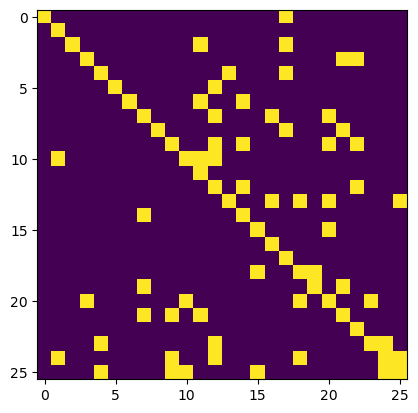

In [2]:
plt.imshow(adj_mtx(np.random.randint(25,40,1)[0])!=0)

## Analysis

In [ ]:
%%time
metrics, N_PASTS, num = [], list(range(1,8)), 20
for a in tqdm(range(num)):
    n_neur, l = np.random.randint(25,40,1)[0], np.random.randint(5000,15000,1)[0]
    alpha, beta, n_lags = 0.01, 0.001, 1
    
    
    # simulate data
    
    A = adj_mtx(n_neur)
    X = np.zeros((A.shape[0], l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A @ X[i] + np.random.normal(0,0.25,A.shape[0])
    X=X.T
    
    print(f'Data {a} of {num} with {X.shape[0]} vars')
    
    # fit algorithm to data
    met = np.zeros((len(N_PASTS),4))
    for k, n_past in enumerate(N_PASTS):
        print(n_past)
        
        # intantiate the GcStar()
        gcstar = GcStar(n_perm = 1000, n_pasts = n_past, n_lags = n_lags, temporal = True)
        gcstar.fit(X, verbose=2)
        
        # compute metrics
        gcstar.get_connectivity_matrix()
        gcstar.compute_confusion_matrix(A)
        met[k] = gcstar.compute_metrics()
    metrics.append(met)

In [4]:
for met in metrics:
    print(met)

[[0.98765432 0.92307692 0.97674419 0.01088647]
 [0.98491084 0.90322581 0.97674419 0.01399689]
 [0.98491084 0.90322581 0.97674419 0.01399689]
 [0.98765432 0.92307692 0.97674419 0.01088647]
 [0.98628258 0.91304348 0.97674419 0.01244168]
 [0.98902606 0.93333333 0.97674419 0.00933126]
 [0.99039781 0.94382022 0.97674419 0.00777605]]
[[0.98       0.93814433 0.88349515 0.00752823]
 [0.98111111 0.94791667 0.88349515 0.00627353]
 [0.98111111 0.94791667 0.88349515 0.00627353]
 [0.98111111 0.94791667 0.88349515 0.00627353]
 [0.97888889 0.92857143 0.88349515 0.00878294]
 [0.98111111 0.94791667 0.88349515 0.00627353]
 [0.97888889 0.92857143 0.88349515 0.00878294]]
[[0.99265306 0.93939394 0.992      0.00727273]
 [0.99265306 0.93939394 0.992      0.00727273]
 [0.99183673 0.93233083 0.992      0.00818182]
 [0.99346939 0.94656489 0.992      0.00636364]
 [0.99102041 0.92537313 0.992      0.00909091]
 [0.99265306 0.93939394 0.992      0.00727273]
 [0.99428571 0.95384615 0.992      0.00545455]]
[[0.999081

In [5]:
Metrics = np.zeros((num,7,4))
for i, met in enumerate(metrics):
    Metrics[i] = met
np.mean(Metrics[:,0,0])

0.9934921007640811

In [6]:
np.mean(Metrics,axis=0)

array([[0.9934921 , 0.97081933, 0.97560548, 0.00402163],
       [0.99314703, 0.9685432 , 0.97560548, 0.0044165 ],
       [0.993694  , 0.97296233, 0.97526991, 0.00374245],
       [0.99319572, 0.96935818, 0.97493434, 0.00426896],
       [0.99288097, 0.96585082, 0.97590282, 0.00476078],
       [0.99328084, 0.96969801, 0.97526991, 0.00421786],
       [0.99281575, 0.96528619, 0.97590282, 0.00484218]])

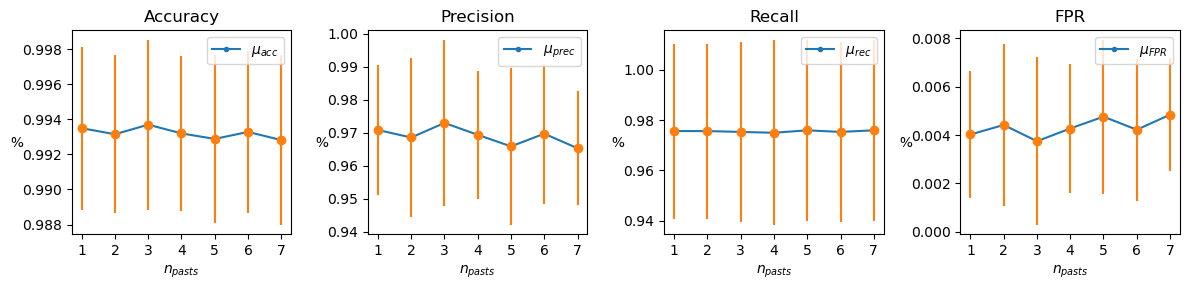

In [8]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3))
labels = ['Accuracy', 'Precision', 'Recall', 'FPR']
lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$']
for i in range(Metrics.shape[2]):
    ax[i].plot(range(1, 1 + Metrics.shape[1]), 
               np.mean(Metrics, axis = 0)[:, i],
               marker = '.', label = lab[i])
    
    ax[i].errorbar(range(1, 1 + Metrics.shape[1]), 
                   np.mean(Metrics, axis = 0)[:, i], 
                   yerr = np.std(Metrics, axis = 0)[:, i], 
                   fmt='o')
    ax[i].set_xticks(range(1,1+Metrics.shape[1]), 
                     list(range(1, 1+Metrics.shape[1])))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
    ax[i].legend()
    plt.tight_layout()